# IIC 2440 – Procesamiento de Datos Masivos
## Tarea 1 — Parte 2: Analítica y MapReduce

---
## Imports y configuración

In [1]:
import os
import sys
import math
import collections
import csv
import functools
import itertools
import re
import unicodedata
from datetime import datetime, timedelta

# Agrega la carpeta del proyecto al path para importar utils
sys.path.insert(0, os.path.dirname(os.path.abspath("utilidades.py")))
from utilidades import (
    leer_warehouse, leer_parquet_simple,
    cargar_dim_region, cargar_dim_source,
    tokenizar, normalizar, STOPWORDS,
    mapreduce, shuffle_and_sort, reduce_list,
    sumar, top_k, contar_tokens_por_clave
)

# RUTAS
WAREHOUSE_PATH  = "data\\warehouse\\fact_news" # carpeta raíz de fact_news
DIM_REGION_PATH = "data\\warehouse\\dim_region\\dim_region.parquet"
DIM_SOURCE_PATH = "data\\warehouse\\dim_source\\dim_source.parquet"
DIM_DATE_PATH   = "data\\warehouse\\dim_date\\dim_date.parquet"

# ==== RUTAS =====
P21 = "resultados/2_1_topk_mensual.csv"
P22 = "resultados/2_2_distribucion_regional.csv"
P23 = "resultados/2_3_divergencia_fuentes.csv"
P24 = "resultados/2_4_peaks.csv"

## Exploración

In [2]:
# Cargar dimensiones
dim_region = cargar_dim_region(DIM_REGION_PATH)
dim_source = cargar_dim_source(DIM_SOURCE_PATH)

print(f"Regiones disponibles ({len(dim_region)}):")
for sk, nombre in sorted(dim_region.items()):
    print(f"  {sk:3d} → {nombre}")

print(f"\nFuentes disponibles: {len(dim_source)}")

Regiones disponibles (17):
    1 → Antofagasta
    2 → Arica y Parinacota
    3 → Atacama
    4 → Aysén
    5 → Biobío
    6 → Coquimbo
    7 → Desconocida
    8 → La Araucanía
    9 → Los Lagos
   10 → Los Ríos
   11 → Magallanes
   12 → Maule
   13 → Metropolitana
   14 → O'Higgins
   15 → Tarapacá
   16 → Valparaíso
   17 → Ñuble

Fuentes disponibles: 106


In [3]:
# Conteo rápido de artículos por año-mes
import pyarrow.parquet as pq

conteo_particiones = {}
for entry in sorted(os.listdir(WAREHOUSE_PATH)):
    if not entry.startswith("year="): continue
    anio = int(entry.split("=")[1])
    year_path = os.path.join(WAREHOUSE_PATH, entry)
    for sub in sorted(os.listdir(year_path)):
        if not sub.startswith("month="): continue
        mes = int(sub.split("=")[1])
        month_path = os.path.join(year_path, sub)
        n = 0
        for f in os.listdir(month_path):
            if not f.endswith(".parquet"): continue
            # Leer solo metadata (no carga datos a memoria)
            meta = pq.read_metadata(os.path.join(month_path, f))
            n += meta.num_rows
        conteo_particiones[f"{anio}-{mes:02d}"] = n

total = sum(conteo_particiones.values())
print(f"Total artículos en warehouse: {total:,}")
print("\nDistribución por año-mes:")
for ym, n in sorted(conteo_particiones.items()):
    print(f"  {ym}: {n:7,}")

Total artículos en warehouse: 1,467,309

Distribución por año-mes:
  2023-01:  39,658
  2023-02:  36,400
  2023-03:  42,342
  2023-04:  37,246
  2023-05:  40,131
  2023-06:  38,436
  2023-07:  31,844
  2023-08:  33,731
  2023-09:  31,827
  2023-10:  40,715
  2023-11:  41,881
  2023-12:  39,231
  2024-01:  44,001
  2024-02:  41,674
  2024-03:  40,609
  2024-04:  43,274
  2024-05:  42,486
  2024-06:  39,736
  2024-07:  44,932
  2024-08:  41,272
  2024-09:  39,929
  2024-10:  46,286
  2024-11:  38,478
  2024-12:  36,824
  2025-01:  38,738
  2025-02:  35,293
  2025-03:  38,588
  2025-04:  43,162
  2025-05:  43,890
  2025-06:  41,502
  2025-07:  42,681
  2025-08:  42,145
  2025-09:  43,992
  2025-10:  50,600
  2025-11:  47,866
  2025-12:  45,909


---
## 2.1: Top-K términos mensuales

In [4]:
topk_mensual = {}
with open(P21, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        ym = row["anio_mes"]
        if ym not in topk_mensual:
            topk_mensual[ym] = []
        topk_mensual[ym].append((row["termino"], int(row["frecuencia"])))

In [5]:
print("Formato: año-mes, término, frecuencia\n")
for ym in sorted(topk_mensual.keys()):
    print(f"== {ym} ==")
    for palabra, cnt in topk_mensual[ym][:5]: # mostramos los 5 primeros
        print(f"   {ym}, {palabra}, {cnt}")
    print()

Formato: año-mes, término, frecuencia

== 2023-01 ==
   2023-01, personas, 18142
   2023-01, gobierno, 16906
   2023-01, quien, 16434
   2023-01, pais, 16299
   2023-01, uno, 15800

== 2023-02 ==
   2023-02, personas, 16409
   2023-02, pais, 14387
   2023-02, quien, 13670
   2023-02, incendios, 13447
   2023-02, uno, 13301

== 2023-03 ==
   2023-03, personas, 17424
   2023-03, quien, 16680
   2023-03, gobierno, 16418
   2023-03, uno, 15759
   2023-03, pais, 15471

== 2023-04 ==
   2023-04, personas, 15835
   2023-04, pais, 14379
   2023-04, esto, 14138
   2023-04, quien, 14031
   2023-04, nacional, 13230

== 2023-05 ==
   2023-05, personas, 17629
   2023-05, quien, 15146
   2023-05, pais, 15036
   2023-05, esto, 14678
   2023-05, uno, 13974

== 2023-06 ==
   2023-06, personas, 16131
   2023-06, pais, 14840
   2023-06, quien, 14798
   2023-06, esto, 14048
   2023-06, uno, 13458

== 2023-07 ==
   2023-07, quien, 13112
   2023-07, estado, 12033
   2023-07, esto, 11990
   2023-07, personas

---
## 2.2: Distribución de palabras por región

In [6]:
resultados_22 = []
with open(P22, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        resultados_22.append({
            "region_sk":     int(row["region_sk"]),
            "region":        row["region"],
            "palabra":       row["palabra"],
            "freq_regional": int(row["freq_regional"]),
            "freq_global":   int(row["freq_global"]),
            "razon":         float(row["razon"]),
        })

print(f"Filas cargadas: {len(resultados_22):,}")
print(f"Ejemplo: {resultados_22[0]}")

Filas cargadas: 1,118,833
Ejemplo: {'region_sk': 13, 'region': 'Metropolitana', 'palabra': 'bulliari', 'freq_regional': 212, 'freq_global': 212, 'razon': 1.0}


In [7]:
# == Post-proceso: calcular razón regional/global ==
resultados_22.sort(key=lambda x: x["razon"], reverse=True)

print("Top 5 palabras con mayor concentración regional:")
for r in resultados_22[:15]:
    print(f"  {r['region']:25s} | {r['palabra']:20s} | reg={r['freq_regional']:6d} | glob={r['freq_global']:8d} | razón={r['razon']:.4f}")


Top 5 palabras con mayor concentración regional:
  Metropolitana             | bulliari             | reg=   212 | glob=     212 | razón=1.0000
  Metropolitana             | paracido             | reg=   188 | glob=     188 | razón=1.0000
  Metropolitana             | ciclorecrevia        | reg=   292 | glob=     292 | razón=1.0000
  Metropolitana             | canopys              | reg=    89 | glob=      89 | razón=1.0000
  Metropolitana             | kellendonk           | reg=   189 | glob=     189 | razón=1.0000
  Metropolitana             | maratoneando         | reg=   189 | glob=     189 | razón=1.0000
  Metropolitana             | flipos               | reg=    82 | glob=      82 | razón=1.0000
  Magallanes                | procien              | reg=    53 | glob=      53 | razón=1.0000
  Biobío                    | sabrael              | reg=    76 | glob=      76 | razón=1.0000
  Los Ríos                  | morrompulli          | reg=   227 | glob=     227 | razón=1.0000
 

---
## Tarea 2.3: Divergencia de vocabulario por fuente

In [8]:
kl_divergencias = []
with open(P23, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        kl_divergencias.append({
            "source_sk":      int(row["source_sk"]),
            "fuente":         row["fuente"],
            "kl_divergencia": float(row["kl_divergencia"]),
            "total_palabras": int(row["total_palabras"]),
        })

In [9]:
kl_divergencias.sort(key=lambda x: x["kl_divergencia"], reverse=True)

print(f"Fuentes analizadas: {len(kl_divergencias)}")
print("\nTop 10 fuentes con mayor divergencia (vocabulario más distinto al global):")
for r in kl_divergencias[:10]:
    print(f"  {r['fuente']:30s} KL={r['kl_divergencia']:.4f}  (palabras={r['total_palabras']:,})")


Fuentes analizadas: 101

Top 10 fuentes con mayor divergencia (vocabulario más distinto al global):
  digital.lasegunda.com          KL=7.2877  (palabras=1,026)
  digital.elmercurio.com         KL=7.1391  (palabras=15,941)
  revo30.org                     KL=5.6562  (palabras=40,827)
  ecovisiones.cl                 KL=4.2222  (palabras=916)
  bnamericas.com                 KL=3.4460  (palabras=855)
  radiopolar.com                 KL=3.4268  (palabras=692)
  diarioantofagasta.cl           KL=3.0751  (palabras=925)
  portaldisc.com                 KL=3.0660  (palabras=11,564)
  diarioelcentro.cl              KL=3.0461  (palabras=1,436)
  canal9.cl                      KL=2.9825  (palabras=1,513)


---
## Tarea 2.4: Detección de peaks


In [10]:
print("MapReduce 2.4: conteo diario...")

def mapper_diario(articulo):
    """Emite (fecha_str, 1) para cada artículo."""
    fecha = articulo.get("publish_date")
    if hasattr(fecha, "strftime"):
        fecha = fecha.strftime("%Y-%m-%d")
    else:
        fecha = str(fecha)[:10]
    return (fecha, 1)

# Una sola pasada MapReduce
pares_diario = list(map(mapper_diario, leer_warehouse("data\\warehouse\\fact_news")))
grupos_diario = shuffle_and_sort(pares_diario)
conteo_diario = dict(reduce_list(sumar, grupos_diario))

print(f"Días con actividad: {len(conteo_diario)}")
print(f"Rango: {min(conteo_diario)} → {max(conteo_diario)}")

MapReduce 2.4: conteo diario...
Días con actividad: 1096
Rango: 2023-01-01 → 2025-12-31


In [11]:
VENTANA_DIAS   = 7
UMBRAL_FACTOR  = 1.3 # Peak si volumen > umbral * promedio_movil

fechas_ordenadas = sorted(conteo_diario.keys())
volumenes = [conteo_diario[f] for f in fechas_ordenadas]

def promedio_movil(serie, ventana):
    """Calcula promedio móvil centrado en i usando ventana días anteriores."""
    resultado = []
    for i in range(len(serie)):
        inicio = max(0, i - ventana)
        ventana_vals = serie[inicio:i]
        if not ventana_vals:
            resultado.append(serie[i])
        else:
            resultado.append(sum(ventana_vals) / len(ventana_vals))
    return resultado

promedios = promedio_movil(volumenes, VENTANA_DIAS)

peaks = []
for i, (fecha, vol) in enumerate(zip(fechas_ordenadas, volumenes)):
    prom = promedios[i]
    if prom > 0 and vol > UMBRAL_FACTOR * prom:
        peaks.append({
            "fecha":           fecha,
            "volumen":         vol,
            "promedio_movil":  round(prom, 1),
            "factor":          round(vol / prom, 2),
        })

peaks.sort(key=lambda x: x["factor"], reverse=True)

print(f"Peaks detectados (factor > {UMBRAL_FACTOR}): {len(peaks)}")
print("\nTop 15 peaks:")
print(f"{'Fecha':12s}  {'Volumen':>8s}  {'Promedio':>10s}  {'Factor':>7s}")
print("-" * 45)
for p in peaks[:15]:
    print(f"{p['fecha']:12s}  {p['volumen']:8,d}  {p['promedio_movil']:10.1f}  {p['factor']:7.2f}x")


Peaks detectados (factor > 1.3): 102

Top 15 peaks:
Fecha          Volumen    Promedio   Factor
---------------------------------------------
2023-01-03       1,536       706.5     2.17x
2023-09-21       1,419       762.6     1.86x
2025-04-02       1,864      1030.9     1.81x
2024-09-24       1,904      1058.1     1.80x
2023-09-20       1,365       761.0     1.79x
2023-09-22       1,388       806.6     1.72x
2023-01-04       1,681       983.0     1.71x
2025-09-23       1,906      1155.7     1.65x
2025-09-24       1,923      1185.4     1.62x
2025-04-03       1,756      1090.1     1.61x
2024-09-25       1,695      1092.0     1.55x
2025-09-25       1,882      1235.6     1.52x
2025-01-07       1,548      1030.1     1.50x
2025-04-04       1,700      1133.4     1.50x
2023-05-10       1,704      1163.0     1.47x


---
## Tarea 2.5: Visualizaciones e informe

Generamos visualizaciones que apoyen el análisis de:
- Tendencias en cobertura mediática
- Vocabulario distintivo por región
- Divergencia por fuente
- Peaks detectados


In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

os.makedirs("resultados/figuras", exist_ok=True)

# Estilo limpio
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

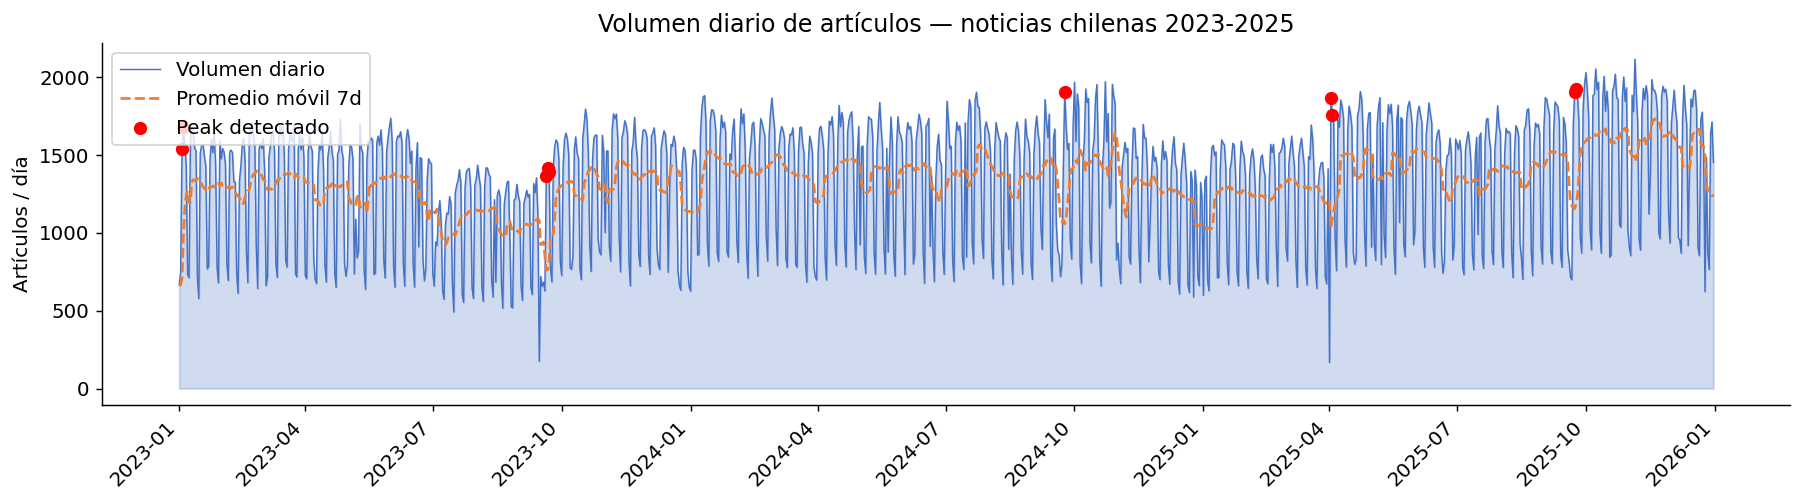

fig1_volumen_peaks.png guardada


In [13]:
# == Figura 1: Volumen diario + peaks ======================================
fig, ax = plt.subplots(figsize=(14, 4))

fechas_dt = [datetime.strptime(f, "%Y-%m-%d") for f in fechas_ordenadas]

ax.fill_between(fechas_dt, volumenes, alpha=0.25, color="#4472C4")
ax.plot(fechas_dt, volumenes, lw=0.8, color="#4472C4", label="Volumen diario")
ax.plot(fechas_dt, promedios, lw=1.5, color="#ED7D31", ls="--", label=f"Promedio móvil {VENTANA_DIAS}d")

# Marcar peaks
peaks_fechas = [datetime.strptime(p["fecha"], "%Y-%m-%d") for p in peaks[:10]]
peaks_vols   = [conteo_diario[p["fecha"]] for p in peaks[:10]]
ax.scatter(peaks_fechas, peaks_vols, color="#FF0000", zorder=5, s=40, label="Peak detectado")

ax.set_title("Volumen diario de artículos — noticias chilenas 2023-2025")
ax.set_ylabel("Artículos / día")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.savefig("resultados/figuras/fig1_volumen_peaks.png", bbox_inches="tight")
plt.show()
print("fig1_volumen_peaks.png guardada")


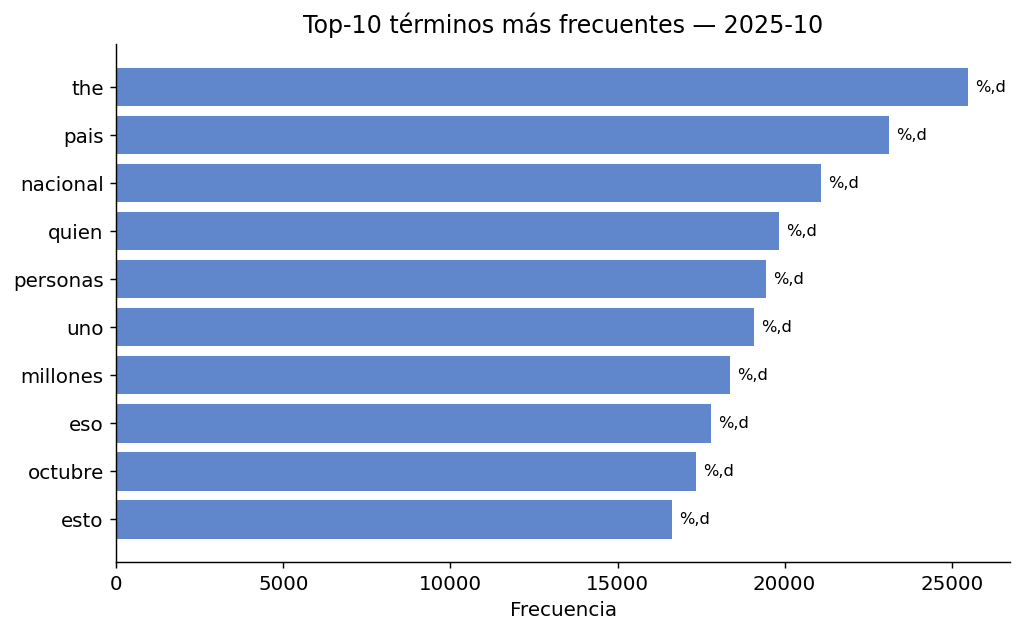

fig2_topk_mes.png guardada (2025-10)


In [14]:
# == Figura 2: Top-10 términos del mes más activo ==========================
mes_max = max(conteo_particiones, key=conteo_particiones.get)
top_mes = topk_mensual.get(mes_max, [])[:10]

if top_mes:
    palabras_bar = [t[0] for t in reversed(top_mes)]
    freqs_bar    = [t[1] for t in reversed(top_mes)]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.barh(palabras_bar, freqs_bar, color="#4472C4", alpha=0.85)
    ax.bar_label(bars, fmt="%,d", padding=4, fontsize=9)
    ax.set_title(f"Top-10 términos más frecuentes — {mes_max}")
    ax.set_xlabel("Frecuencia")
    plt.tight_layout()
    plt.savefig("resultados/figuras/fig2_topk_mes.png", bbox_inches="tight")
    plt.show()
    print(f"fig2_topk_mes.png guardada ({mes_max})")


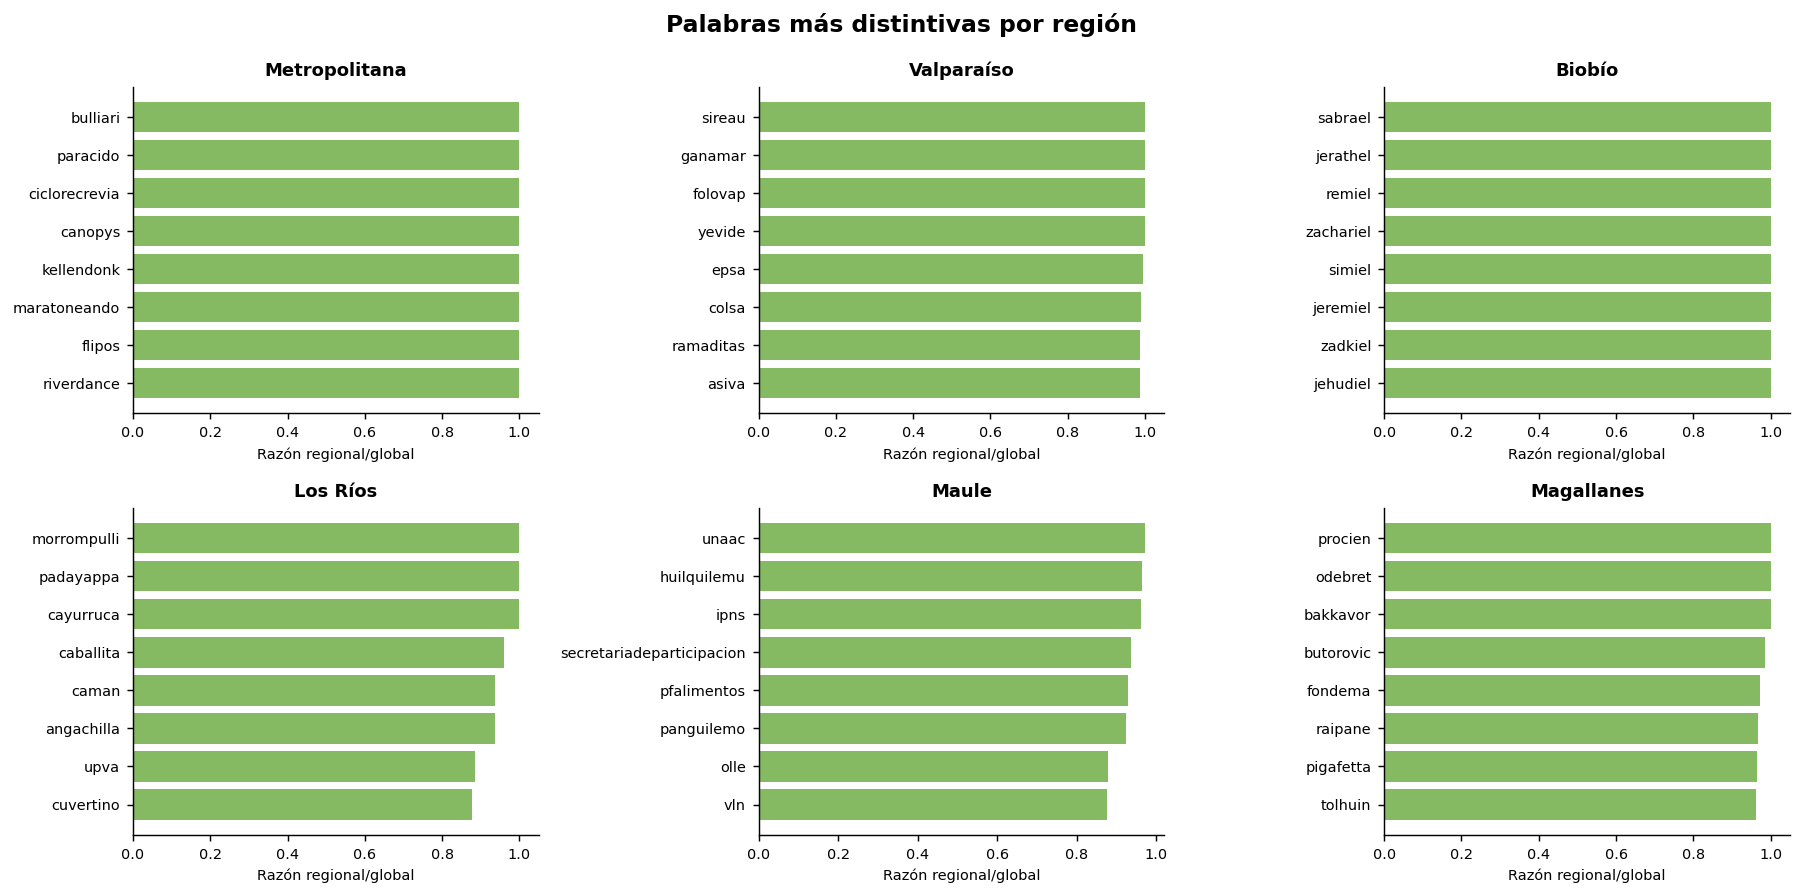

fig3_palabras_region.png guardada


In [15]:
# == Figura 3: Palabras más distintivas por región (top razón) =============
# Seleccionar top-3 palabras por región según razón regional/global
from collections import defaultdict

top_por_region = defaultdict(list)
for r in resultados_22:
    top_por_region[r["region"]].append((r["palabra"], r["razon"]))

# Tomar las 5 regiones con más artículos y sus top-3 palabras
regiones_plot = sorted(
    top_por_region.keys(),
    key=lambda rg: sum(rr["freq_regional"] for rr in resultados_22 if rr["region"] == rg),
    reverse=True
)[:6]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for ax, region in zip(axes, regiones_plot):
    datos = sorted(top_por_region[region], key=lambda x: x[1], reverse=True)[:8]
    if not datos: continue
    pals = [d[0] for d in reversed(datos)]
    razones = [d[1] for d in reversed(datos)]
    bars = ax.barh(pals, razones, color="#70AD47", alpha=0.85)
    ax.set_title(region, fontsize=10, fontweight="bold")
    ax.set_xlabel("Razón regional/global", fontsize=8)
    ax.tick_params(labelsize=8)

plt.suptitle("Palabras más distintivas por región", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("resultados/figuras/fig3_palabras_region.png", bbox_inches="tight")
plt.show()
print("fig3_palabras_region.png guardada")


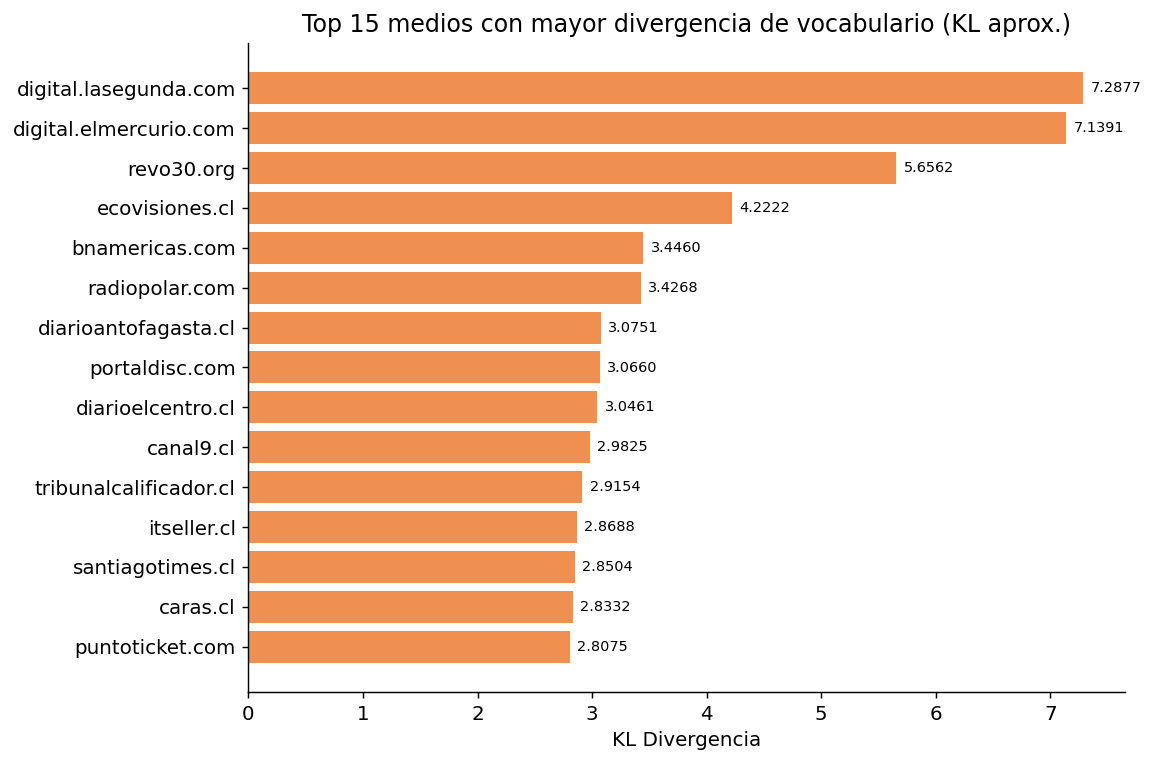

fig4_kl_fuentes.png guardada


In [16]:
# == Figura 4: Top-15 fuentes por divergencia KL ===========================
top_kl = kl_divergencias[:15]
fuentes_plot = [r["fuente"] for r in reversed(top_kl)]
kl_vals      = [r["kl_divergencia"] for r in reversed(top_kl)]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(fuentes_plot, kl_vals, color="#ED7D31", alpha=0.85)
ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=8)
ax.set_title("Top 15 medios con mayor divergencia de vocabulario (KL aprox.)")
ax.set_xlabel("KL Divergencia")
plt.tight_layout()
plt.savefig("resultados/figuras/fig4_kl_fuentes.png", bbox_inches="tight")
plt.show()
print("fig4_kl_fuentes.png guardada")


---
## Análisis y conclusiones

> **Completa esta sección en el informe.**

### Tendencias generales
- (Describe los términos que dominaron cada período)
- (Menciona cambios en la cobertura entre 2023 y 2025)

### Vocabulario por región
- (¿Qué regiones tienen un vocabulario más diferenciado?)
- (¿Hay eventos locales que expliquen las palabras distintivas?)

### Divergencia por fuente
- (¿Qué tipo de medios tienen mayor divergencia? ¿Especializados, locales, nacionales?)
- (¿Hay algún patrón en los medios con vocabulario más genérico?)

### Peaks detectados
- (Analiza los 3–5 peaks más prominentes)
- (¿Qué eventos nacionales o internacionales podrían explicarlos?)
